# RFMI Extraction Framework and Reproducible Workflow Demo

This notebook is organized as a six-part demonstration of the public RFMI extraction framework. Each part contains executable code, a short explanation, and the output produced from one synthetic open-eye child facial image.

The public workflow includes image preparation, MediaPipe Face Landmarker detection, coordinate-based overlay figures, a blank manual quality-control template for blinded assessment, RFMI calculation, and output tables. The example image is synthetic and is not study data.

This notebook demonstrates the core RFMI extraction framework. Study-specific steps such as completed human QC, sensitivity analysis, test-retest assessment, and comparisons with reference measurements are outside the synthetic demonstration.


## Part 1. Environment Setup and Synthetic Input Image

This part checks the pinned direct-dependency environment, locates the repository root, imports the required Python libraries, and displays the clean synthetic open-eye child image. The expected results are a runtime-version table, the resolved project path, and the starting image used in this public demo.

Runtime environment: pinned direct-dependency versions verified


,Component,Version
0,Python,3.13.9
1,mediapipe,0.10.35
2,pillow,12.3.0
3,pandas,2.3.3
4,numpy,2.3.3
5,matplotlib,3.10.7
6,openpyxl,3.1.5
7,jupyter,1.1.1


Python executable: python.exe
Project root folder: rfmi_public_demo_final


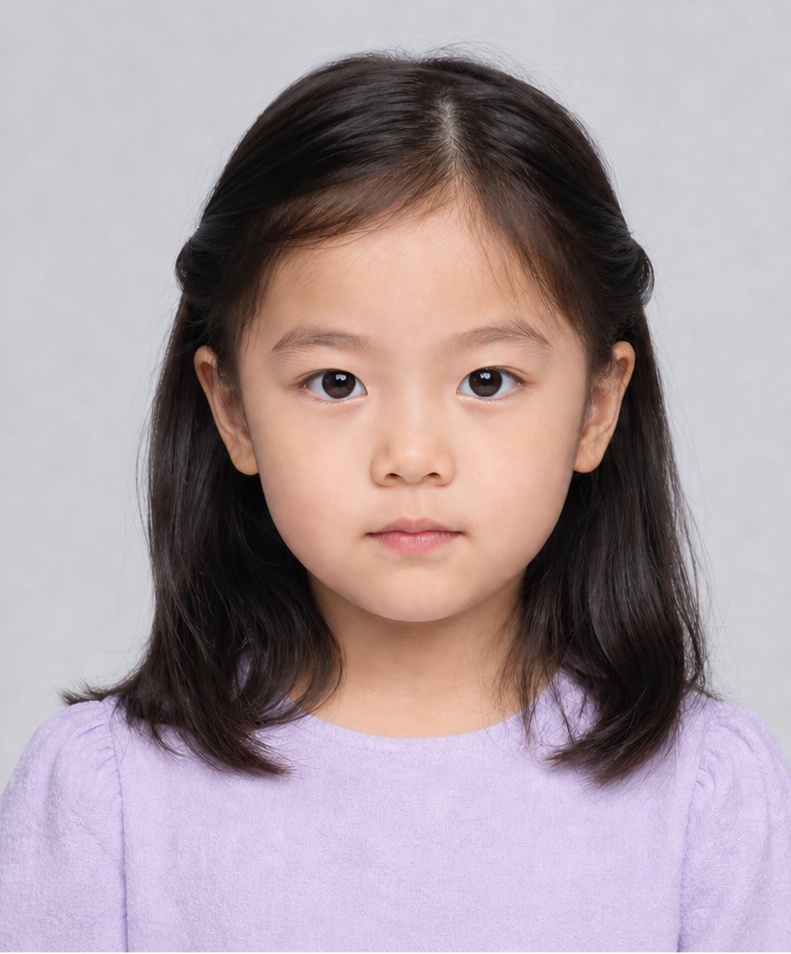

In [1]:
from pathlib import Path
from importlib.metadata import version as distribution_version
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

INSTALL = False

# Optional manual override. Use this only if automatic root detection fails.
# Example: ROOT_OVERRIDE = Path(r'C:\\path\to\mediapipe_child_face_analysis_RFMI')
ROOT_OVERRIDE = None

def looks_like_project_root(path):
    path = Path(path)
    return (path / 'requirements.txt').exists() and (path / 'scripts' / '01_prepare_project.py').exists()

def find_project_root():
    candidates = []
    if ROOT_OVERRIDE is not None:
        candidates.append(Path(ROOT_OVERRIDE))
    cwd = Path.cwd().resolve()
    candidates.extend([cwd, *cwd.parents])
    for candidate in candidates:
        candidate = candidate.resolve()
        if looks_like_project_root(candidate):
            return candidate
    raise FileNotFoundError('Project root was not found. Set ROOT_OVERRIDE to the repository folder.')

ROOT = find_project_root()

def read_pinned_environment(root):
    expected_python = (root / '.python-version').read_text(encoding='utf-8').strip()
    expected_distributions = {}
    for raw_line in (root / 'requirements.txt').read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#'):
            continue
        if '==' not in line:
            raise RuntimeError(f'Requirement is not exactly pinned: {line}')
        name, expected = line.split('==', maxsplit=1)
        expected_distributions[name.strip().lower()] = expected.strip()
    return expected_python, expected_distributions

EXPECTED_PYTHON, EXPECTED_DISTRIBUTIONS = read_pinned_environment(ROOT)

if INSTALL:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(ROOT / 'requirements.txt')], check=True)

runtime_python = '.'.join(str(value) for value in sys.version_info[:3])
runtime_versions = {name: distribution_version(name) for name in EXPECTED_DISTRIBUTIONS}
mismatches = []
if runtime_python != EXPECTED_PYTHON:
    mismatches.append(f'Python: expected {EXPECTED_PYTHON}, found {runtime_python}')
for name, expected in EXPECTED_DISTRIBUTIONS.items():
    if runtime_versions[name] != expected:
        mismatches.append(f'{name}: expected {expected}, found {runtime_versions[name]}')
if mismatches:
    raise RuntimeError('Runtime environment does not match the pinned direct-dependency specification:\n' + '\n'.join(mismatches))

runtime_table = pd.DataFrame(
    [('Python', runtime_python), *[(name, runtime_versions[name]) for name in EXPECTED_DISTRIBUTIONS]],
    columns=['Component', 'Version'],
)

OPEN_IMAGE = ROOT / 'example_data' / 'images' / 'SYN_open.jpg'
SUBJECT_ID = 'SYN'

print('Runtime environment: pinned direct-dependency versions verified')
display(runtime_table)
print('Python executable:', Path(sys.executable).name)
print('Project root folder:', ROOT.name)
display(Image(filename=str(OPEN_IMAGE), width=430))


## Part 2. Manifest Creation

This part writes a manifest file for the synthetic open-eye example image. The expected output is `outputs_manifest/manifest.csv`, which records the subject identifier, image state, and copied analysis path.

In [2]:
def display_argument(value):
    text = str(value)
    try:
        return str(Path(text).relative_to(ROOT))
    except (ValueError, OSError):
        return text

def run(args):
    cmd = [sys.executable] + [str(a) for a in args]
    print('RUN:', ' '.join(['python', *[display_argument(a) for a in args]]))
    subprocess.run(cmd, cwd=ROOT, check=True)

run([
    ROOT / 'scripts' / '01_prepare_project.py',
    '--root', ROOT,
    '--open-image', OPEN_IMAGE,
    '--child-id', SUBJECT_ID,
])

manifest = pd.read_csv(ROOT / 'outputs_manifest' / 'manifest.csv')
manifest

RUN: python scripts\01_prepare_project.py --root . --open-image example_data\images\SYN_open.jpg --child-id SYN


,child_id,state,open_analysis_path,has_open
0,SYN,open,data\images_analysis\SYN_open.jpg,True


## Part 3. MediaPipe Landmark Detection

This part runs MediaPipe Face Landmarker and exports raw landmark coordinates. The expected outputs are `landmarks_raw.csv` with 478 coordinate rows for the example image and `detection_log.csv`.

In [3]:
run([ROOT / 'scripts' / '02_detect_and_overlay.py', '--root', ROOT])

landmarks = pd.read_csv(ROOT / 'outputs_landmarks' / 'landmarks_raw.csv')
detection_log = pd.read_csv(ROOT / 'outputs_landmarks' / 'detection_log.csv')

print('Landmark rows:', len(landmarks))
display(detection_log)
landmarks.head()

RUN: python scripts\02_detect_and_overlay.py --root .


Landmark rows: 478


,child_id,state,image_id,image_path,width,height,n_faces,detection_success,error,full_overlay_path,eye_zoom_path,rfmi_line_overlay_path
0,SYN,open,SYN_open,data\images_analysis\SYN_open.jpg,791,954,1,True,NaN,outputs_overlay\full_face\SYN_open_overlay.jpg,outputs_overlay\eye_zoom\SYN_open_eye_zoom.jpg,outputs_overlay\rfmi_lines\SYN_open_rfmi_lines...


,image_id,child_id,state,landmark_index,x_norm,y_norm,z_norm,x_px,y_px
0,SYN_open,SYN,open,0,0.526064,0.545088,-0.047143,416.116654,520.013718
1,SYN_open,SYN,open,1,0.521941,0.498061,-0.095938,412.855100,475.149854
2,SYN_open,SYN,open,2,0.523204,0.511694,-0.047151,413.854292,488.155691
3,SYN_open,SYN,open,3,0.505528,0.449680,-0.075093,399.872627,428.994948
4,SYN_open,SYN,open,4,0.521332,0.483271,-0.103344,412.373538,461.040650


## Part 4. Coordinate-Based Overlay Figures and QC Template

This part displays three visual outputs: full-face landmarks, an eye-region zoom, and the RFMI distance-line overlay. These figures are generated from MediaPipe coordinates; no landmarks are manually placed.

It also creates a blank manual quality-control template for blinded assessment. The template does not implement blinding by itself; a real study must mask identifiers, randomize review order, and manage rater files under a prespecified protocol. The public demo does not include real human ratings.


SYN_open_overlay.jpg


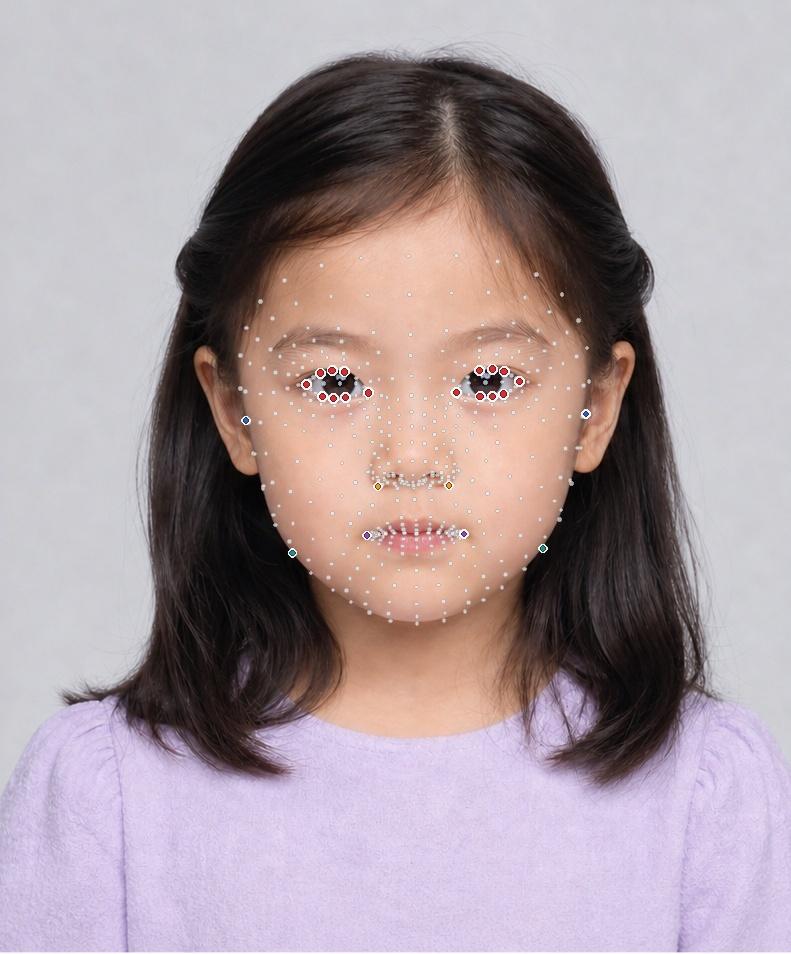

SYN_open_eye_zoom.jpg


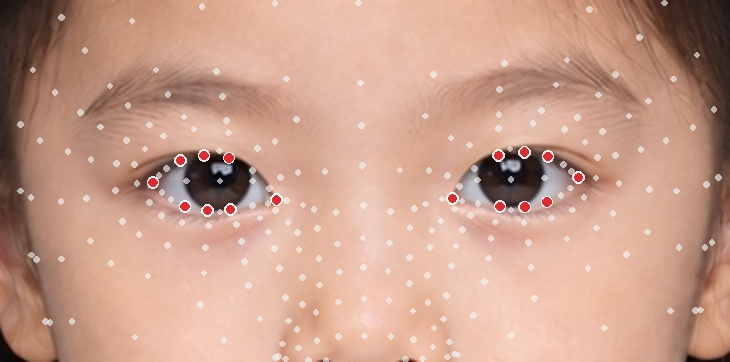

SYN_open_rfmi_lines.jpg


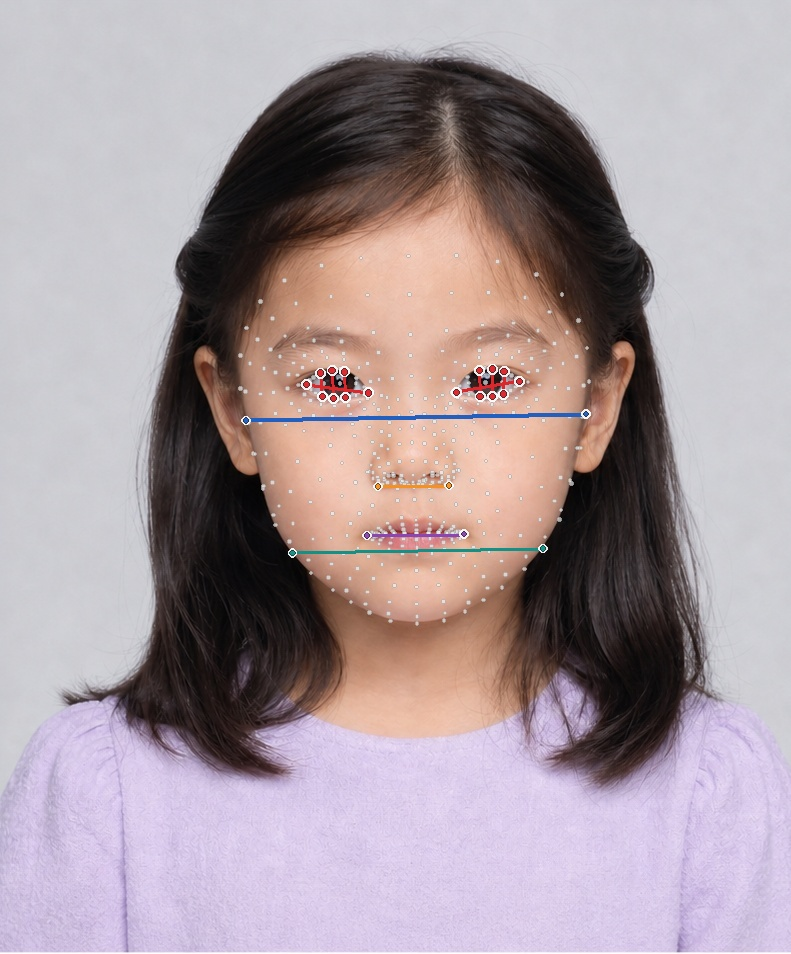

RUN: python scripts\03_generate_qc_template.py --root .


,image_id,subject_id,state,detection_success,full_face_overlay,eye_zoom_overlay,rfmi_lines_overlay,rater_id,overall_score,eye_region_score,nose_mouth_score,facial_outline_score,include_main_analysis,comments
0,SYN_open,SYN,open,True,outputs_overlay\full_face\SYN_open_overlay.jpg,outputs_overlay\eye_zoom\SYN_open_eye_zoom.jpg,outputs_overlay\rfmi_lines\SYN_open_rfmi_lines...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,field,dimension,score_0,score_1,score_2
0,overall_score,Overall face,Not usable: major landmark displacement or unu...,Borderline: face detected but local mismatch r...,Usable: main landmarks align with the visible ...
1,eye_region_score,Eye region,Not usable: eye landmarks clearly miss the vis...,Borderline: mild local mismatch or partial amb...,Usable: eye landmarks are consistent with the ...
2,nose_mouth_score,Nose-mouth region,Not usable: nose or mouth landmarks clearly mi...,Borderline: mild local mismatch or partial amb...,Usable: nose and mouth landmarks are consisten...
3,facial_outline_score,Facial outline,Not usable: facial outline landmarks are clear...,Borderline: mild outline mismatch or partial o...,Usable: facial outline landmarks are consisten...


In [4]:
image_id = f'{SUBJECT_ID}_open'
overlay_paths = [
    ROOT / 'outputs_overlay' / 'full_face' / f'{image_id}_overlay.jpg',
    ROOT / 'outputs_overlay' / 'eye_zoom' / f'{image_id}_eye_zoom.jpg',
    ROOT / 'outputs_overlay' / 'rfmi_lines' / f'{image_id}_rfmi_lines.jpg',
]

for path in overlay_paths:
    print(path.name)
    display(Image(filename=str(path), width=650))

run([ROOT / 'scripts' / '03_generate_qc_template.py', '--root', ROOT])
qc_template = pd.read_csv(ROOT / 'outputs_qc' / 'qc_template.csv')
qc_codebook = pd.read_csv(ROOT / 'outputs_qc' / 'qc_score_codebook.csv')

display(qc_template)
display(qc_codebook)


## Part 5. RFMI Index Calculation

This part converts selected MediaPipe landmark coordinate groups into RFMI variables. Single eye-region variables are named by landmark index groups, such as `eye_33_133_aperture_index` and `eye_263_362_aperture_index`, rather than anatomical left/right labels.

The output table has one row per image or subject and one column per RFMI feature.


In [5]:
run([ROOT / 'scripts' / '04_compute_rfmi.py', '--root', ROOT])

rfmi_image = pd.read_csv(ROOT / 'outputs_features' / 'rfmi_image_level.csv')
rfmi_subject = pd.read_csv(ROOT / 'outputs_features' / 'rfmi_subject_level.csv')

display(rfmi_image)
display(rfmi_subject)

RUN: python scripts\04_compute_rfmi.py --root .


,image_id,child_id,state,include_source,face_width_px,eye_33_133_aperture_index,eye_263_362_aperture_index,mean_eye_aperture_index,eye_aperture_asymmetry_index,nose_width_face_width_index,mouth_width_face_width_index,jaw_width_face_width_index,eyeBlinkLeft,eyeBlinkRight,eyeWideLeft,eyeWideRight,eyeSquintLeft,eyeSquintRight
0,SYN_open,SYN,open,detection_success,340.413366,0.410014,0.396083,0.403048,0.013931,0.210269,0.286102,0.736664,0.022133,0.007761,0.03579,0.092646,0.056086,0.055109


,image_id,child_id,state,include_source,face_width_px,eye_33_133_aperture_index,eye_263_362_aperture_index,mean_eye_aperture_index,eye_aperture_asymmetry_index,nose_width_face_width_index,mouth_width_face_width_index,jaw_width_face_width_index,eyeBlinkLeft,eyeBlinkRight,eyeWideLeft,eyeWideRight,eyeSquintLeft,eyeSquintRight
0,SYN_open,SYN,open,detection_success,340.413366,0.410014,0.396083,0.403048,0.013931,0.210269,0.286102,0.736664,0.022133,0.007761,0.03579,0.092646,0.056086,0.055109


## Part 6. Summary Tables and Output Checklist

This part creates the subject-level RFMI table and the descriptive summary table. It also lists the main output files so readers can quickly check what the workflow generated.

In [6]:
run([ROOT / 'scripts' / '05_summarize_rfmi.py', '--root', ROOT])

subject_table = pd.read_csv(ROOT / 'outputs_stats' / 'tables' / 'rfmi_subject_indices.csv')
summary_table = pd.read_csv(ROOT / 'outputs_stats' / 'tables' / 'rfmi_summary.csv')

display(subject_table)
display(summary_table)

main_outputs = [
    ROOT / 'outputs_manifest' / 'manifest.csv',
    ROOT / 'outputs_landmarks' / 'landmarks_raw.csv',
    ROOT / 'outputs_landmarks' / 'detection_log.csv',
    ROOT / 'outputs_overlay' / 'full_face' / f'{image_id}_overlay.jpg',
    ROOT / 'outputs_overlay' / 'eye_zoom' / f'{image_id}_eye_zoom.jpg',
    ROOT / 'outputs_overlay' / 'rfmi_lines' / f'{image_id}_rfmi_lines.jpg',
    ROOT / 'outputs_qc' / 'qc_template.csv',
    ROOT / 'outputs_qc' / 'qc_score_codebook.csv',
    ROOT / 'outputs_features' / 'rfmi_image_level.csv',
    ROOT / 'outputs_features' / 'rfmi_subject_level.csv',
    ROOT / 'outputs_stats' / 'tables' / 'rfmi_subject_indices.csv',
    ROOT / 'outputs_stats' / 'tables' / 'rfmi_summary.csv',
]

for path in main_outputs:
    print(path.relative_to(ROOT), 'exists=', path.exists())


RUN: python scripts\05_summarize_rfmi.py --root .


,image_id,subject_id,state,include_source,face_width_px,eye_33_133_aperture_index,eye_263_362_aperture_index,mean_eye_aperture_index,eye_aperture_asymmetry_index,nose_width_face_width_index,mouth_width_face_width_index,jaw_width_face_width_index,eyeBlinkLeft,eyeBlinkRight,eyeWideLeft,eyeWideRight,eyeSquintLeft,eyeSquintRight
0,SYN_open,SYN,open,detection_success,340.413366,0.410014,0.396083,0.403048,0.013931,0.210269,0.286102,0.736664,0.022133,0.007761,0.03579,0.092646,0.056086,0.055109


,metric,label,category,n,mean,sd,median,min,max,mean_sd
0,eye_33_133_aperture_index,33-133 eye-region aperture index,Eye geometry,1,0.410014,NaN,0.410014,0.410014,0.410014,0.410 +/- NA
1,eye_263_362_aperture_index,263-362 eye-region aperture index,Eye geometry,1,0.396083,NaN,0.396083,0.396083,0.396083,0.396 +/- NA
2,mean_eye_aperture_index,Mean eye-region aperture index,Eye geometry,1,0.403048,NaN,0.403048,0.403048,0.403048,0.403 +/- NA
3,eye_aperture_asymmetry_index,Eye aperture asymmetry index,Eye geometry,1,0.013931,NaN,0.013931,0.013931,0.013931,0.014 +/- NA
4,nose_width_face_width_index,Nose-width/face-width index,Face ratio,1,0.210269,NaN,0.210269,0.210269,0.210269,0.210 +/- NA
5,mouth_width_face_width_index,Mouth-width/face-width index,Face ratio,1,0.286102,NaN,0.286102,0.286102,0.286102,0.286 +/- NA
6,jaw_width_face_width_index,Jaw-width/face-width index,Face ratio,1,0.736664,NaN,0.736664,0.736664,0.736664,0.737 +/- NA
7,eyeBlinkLeft,MediaPipe eyeBlinkLeft auxiliary score,Eye-state auxiliary score,1,0.022133,NaN,0.022133,0.022133,0.022133,0.022 +/- NA
8,eyeBlinkRight,MediaPipe eyeBlinkRight auxiliary score,Eye-state auxiliary score,1,0.007761,NaN,0.007761,0.007761,0.007761,0.008 +/- NA


outputs_manifest\manifest.csv exists= True
outputs_landmarks\landmarks_raw.csv exists= True
outputs_landmarks\detection_log.csv exists= True
outputs_overlay\full_face\SYN_open_overlay.jpg exists= True
outputs_overlay\eye_zoom\SYN_open_eye_zoom.jpg exists= True
outputs_overlay\rfmi_lines\SYN_open_rfmi_lines.jpg exists= True
outputs_qc\qc_template.csv exists= True
outputs_qc\qc_score_codebook.csv exists= True
outputs_features\rfmi_image_level.csv exists= True
outputs_features\rfmi_subject_level.csv exists= True
outputs_stats\tables\rfmi_subject_indices.csv exists= True
outputs_stats\tables\rfmi_summary.csv exists= True
